# Projet

In [1]:
import findspark
findspark.init()
findspark.find()
import pyspark
from pyspark import SparkContext
from pyspark.sql import SparkSession, SQLContext

In [2]:
sc=SparkContext()

23/01/30 14:10:40 WARN Utils: Your hostname, LAPTOP-CUMRVF08 resolves to a loopback address: 127.0.1.1; using 172.20.42.74 instead (on interface eth0)
23/01/30 14:10:40 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


23/01/30 14:10:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
spark = SparkSession(sc)

In [4]:
df = "../data/country_level_data_0.csv"

## Exploration des données

In [5]:
dataset = spark.read.csv(df,inferSchema=True,header =True)

In [6]:
from pyspark.sql.functions import col, count, isnan, when,lit,round
from pyspark.sql.types import DoubleType
from pyspark.sql.types import IntegerType,BooleanType,DateType,StringType
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [7]:
dataset.printSchema()

root
 |-- region_id: string (nullable = true)
 |-- country_name: string (nullable = true)
 |-- gdp: string (nullable = true)
 |-- composition_food_organic_waste_percent: string (nullable = true)
 |-- composition_glass_percent: string (nullable = true)
 |-- composition_metal_percent: string (nullable = true)
 |-- composition_other_percent: string (nullable = true)
 |-- composition_paper_cardboard_percent: string (nullable = true)
 |-- composition_plastic_percent: string (nullable = true)
 |-- composition_rubber_leather_percent: string (nullable = true)
 |-- composition_wood_percent: string (nullable = true)
 |-- composition_yard_garden_green_waste_percent: string (nullable = true)
 |-- other_information_information_system_for_solid_waste_management: string (nullable = true)
 |-- other_information_national_agency_to_enforce_solid_waste_laws_and_regulations: string (nullable = true)
 |-- other_information_national_law_governing_solid_waste_management_in_the_country: string (nullable = tru

In [8]:
dataset.head(2)

23/01/30 14:10:54 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


[Row(region_id='LCN', country_name='Aruba', gdp='35563.3125', composition_food_organic_waste_percent='NA', composition_glass_percent='NA', composition_metal_percent='NA', composition_other_percent='NA', composition_paper_cardboard_percent='NA', composition_plastic_percent='NA', composition_rubber_leather_percent='NA', composition_wood_percent='NA', composition_yard_garden_green_waste_percent='NA', other_information_information_system_for_solid_waste_management='NA', other_information_national_agency_to_enforce_solid_waste_laws_and_regulations='Yes', other_information_national_law_governing_solid_waste_management_in_the_country='Yes', other_information_ppp_rules_and_regulations='Yes', other_information_summary_of_key_solid_waste_information_made_available_to_the_public='Yes', population_population_number_of_people=103187, special_waste_agricultural_waste_tons_year='NA', special_waste_construction_and_demolition_waste_tons_year='NA', special_waste_e_waste_tons_year='NA', special_waste_ha

In [9]:
df1 = dataset
df1.dropDuplicates()

DataFrame[region_id: string, country_name: string, gdp: string, composition_food_organic_waste_percent: string, composition_glass_percent: string, composition_metal_percent: string, composition_other_percent: string, composition_paper_cardboard_percent: string, composition_plastic_percent: string, composition_rubber_leather_percent: string, composition_wood_percent: string, composition_yard_garden_green_waste_percent: string, other_information_information_system_for_solid_waste_management: string, other_information_national_agency_to_enforce_solid_waste_laws_and_regulations: string, other_information_national_law_governing_solid_waste_management_in_the_country: string, other_information_ppp_rules_and_regulations: string, other_information_summary_of_key_solid_waste_information_made_available_to_the_public: string, population_population_number_of_people: int, special_waste_agricultural_waste_tons_year: string, special_waste_construction_and_demolition_waste_tons_year: string, special_wa

In [10]:
df2 = df1.drop(
            'composition_rubber_leather_percent',
            'composition_wood_percent',
            'composition_yard_garden_green_waste_percent',
            'other_information_summary_of_key_solid_waste_information_made_available_to_the_public',
            'special_waste_agricultural_waste_tons_year',
            'special_waste_construction_and_demolition_waste_tons_year',
            'special_waste_industrial_waste_tons_year',
            'special_waste_medical_waste_tons_year',
            'waste_collection_coverage_rural_percent_of_geographic_area',
            'waste_collection_coverage_rural_percent_of_households',
            'waste_collection_coverage_rural_percent_of_population',
            'waste_collection_coverage_rural_percent_of_waste',
            'waste_collection_coverage_total_percent_of_geographic_area',
            'waste_collection_coverage_total_percent_of_households',
            'waste_collection_coverage_total_percent_of_population',
            'waste_collection_coverage_total_percent_of_waste',            
            'waste_collection_coverage_urban_percent_of_geographic_area',
            'waste_collection_coverage_urban_percent_of_households',
            'waste_collection_coverage_urban_percent_of_population',
            'waste_collection_coverage_urban_percent_of_waste',
            'waste_treatment_anaerobic_digestion_percent',
            'waste_treatment_compost_percent',
            'waste_treatment_other_percent',
            'waste_treatment_controlled_landfill_percent',
            'waste_treatment_incineration_percent',
            'waste_treatment_landfill_unspecified_percent',
            'waste_treatment_open_dump_percent',
            'waste_treatment_sanitary_landfill_landfill_gas_system_percent',
            'waste_treatment_waterways_marine_percent',
            'where_where_is_this_data_measured',
            
            'waste_treatment_unaccounted_for_percent',
            )

In [11]:
df2.head(2)

[Row(region_id='LCN', country_name='Aruba', gdp='35563.3125', composition_food_organic_waste_percent='NA', composition_glass_percent='NA', composition_metal_percent='NA', composition_other_percent='NA', composition_paper_cardboard_percent='NA', composition_plastic_percent='NA', other_information_information_system_for_solid_waste_management='NA', other_information_national_agency_to_enforce_solid_waste_laws_and_regulations='Yes', other_information_national_law_governing_solid_waste_management_in_the_country='Yes', other_information_ppp_rules_and_regulations='Yes', population_population_number_of_people=103187, special_waste_e_waste_tons_year='NA', special_waste_hazardous_waste_tons_year='NA', total_msw_total_msw_generated_tons_year='88132.0167', waste_treatment_recycling_percent='11'),
 Row(region_id='SAS', country_name='Afghanistan', gdp='2057.062256', composition_food_organic_waste_percent='NA', composition_glass_percent='NA', composition_metal_percent='NA', composition_other_percent

In [12]:
for col in df2.columns:
    print(col,"with null values: ", df2.filter(df2[col].isNull()).count())

region_id with null values:  0
country_name with null values:  0
gdp with null values:  0
composition_food_organic_waste_percent with null values:  0
composition_glass_percent with null values:  0
composition_metal_percent with null values:  0
composition_other_percent with null values:  0
composition_paper_cardboard_percent with null values:  0
composition_plastic_percent with null values:  0
other_information_information_system_for_solid_waste_management with null values:  0
other_information_national_agency_to_enforce_solid_waste_laws_and_regulations with null values:  0
other_information_national_law_governing_solid_waste_management_in_the_country with null values:  0
other_information_ppp_rules_and_regulations with null values:  0
population_population_number_of_people with null values:  0
special_waste_e_waste_tons_year with null values:  0
special_waste_hazardous_waste_tons_year with null values:  0
total_msw_total_msw_generated_tons_year with null values:  0
waste_treatment_rec

In [13]:
for col in df2.columns:
    print(col,"with null values: ", df2.filter(df2[col]=="NA").count())

region_id with null values:  0
country_name with null values:  1
gdp with null values:  1
composition_food_organic_waste_percent with null values:  41
composition_glass_percent with null values:  46
composition_metal_percent with null values:  47
composition_other_percent with null values:  42
composition_paper_cardboard_percent with null values:  41
composition_plastic_percent with null values:  42
other_information_information_system_for_solid_waste_management with null values:  105
other_information_national_agency_to_enforce_solid_waste_laws_and_regulations with null values:  53
other_information_national_law_governing_solid_waste_management_in_the_country with null values:  23
other_information_ppp_rules_and_regulations with null values:  55
population_population_number_of_people with null values:  0
special_waste_e_waste_tons_year with null values:  35
special_waste_hazardous_waste_tons_year with null values:  99
total_msw_total_msw_generated_tons_year with null values:  2
waste_

In [14]:
df2.filter(df2["gdp"] == "NA").collect()

[Row(region_id='LCN', country_name='Sint Maarten (Dutch part)', gdp='NA', composition_food_organic_waste_percent='46', composition_glass_percent='7', composition_metal_percent='7', composition_other_percent='12', composition_paper_cardboard_percent='15', composition_plastic_percent='13', other_information_information_system_for_solid_waste_management='NA', other_information_national_agency_to_enforce_solid_waste_laws_and_regulations='Yes', other_information_national_law_governing_solid_waste_management_in_the_country='Yes', other_information_ppp_rules_and_regulations='NA', population_population_number_of_people=37685, special_waste_e_waste_tons_year='NA', special_waste_hazardous_waste_tons_year='NA', total_msw_total_msw_generated_tons_year='NA', waste_treatment_recycling_percent='NA')]

In [15]:
df2 = df2.replace("NA",None)

In [16]:
for col in df2.columns:
    print(col,"with null values: ", df2.filter(df2[col].isNull()).count())

region_id with null values:  0
country_name with null values:  1
gdp with null values:  1
composition_food_organic_waste_percent with null values:  41
composition_glass_percent with null values:  46
composition_metal_percent with null values:  47
composition_other_percent with null values:  42
composition_paper_cardboard_percent with null values:  41
composition_plastic_percent with null values:  42
other_information_information_system_for_solid_waste_management with null values:  105
other_information_national_agency_to_enforce_solid_waste_laws_and_regulations with null values:  53
other_information_national_law_governing_solid_waste_management_in_the_country with null values:  23
other_information_ppp_rules_and_regulations with null values:  55
population_population_number_of_people with null values:  0
special_waste_e_waste_tons_year with null values:  35
special_waste_hazardous_waste_tons_year with null values:  99
total_msw_total_msw_generated_tons_year with null values:  2
waste_

### convertion String to Double

In [17]:
#df2 = df2.withColumn("gdp",df2.gdp.cast(DoubleType()))

#df2=df2.withColumn('gdp',round(df2.gdp.cast(DoubleType()),2))

In [18]:
col_str = ['gdp','composition_food_organic_waste_percent','composition_glass_percent','composition_metal_percent','composition_other_percent','composition_paper_cardboard_percent','composition_plastic_percent','special_waste_e_waste_tons_year','special_waste_hazardous_waste_tons_year','total_msw_total_msw_generated_tons_year','waste_treatment_recycling_percent']
for col in col_str :
    df2 = df2.withColumn(col,df2[col].cast(DoubleType()))
    #df2 = df2.withColumn(col,round(df2[col].cast(DoubleType()),2))

In [19]:
df2.printSchema

<bound method DataFrame.printSchema of DataFrame[region_id: string, country_name: string, gdp: double, composition_food_organic_waste_percent: double, composition_glass_percent: double, composition_metal_percent: double, composition_other_percent: double, composition_paper_cardboard_percent: double, composition_plastic_percent: double, other_information_information_system_for_solid_waste_management: string, other_information_national_agency_to_enforce_solid_waste_laws_and_regulations: string, other_information_national_law_governing_solid_waste_management_in_the_country: string, other_information_ppp_rules_and_regulations: string, population_population_number_of_people: int, special_waste_e_waste_tons_year: double, special_waste_hazardous_waste_tons_year: double, total_msw_total_msw_generated_tons_year: double, waste_treatment_recycling_percent: double]>

In [20]:
df2.head(5)

[Row(region_id='LCN', country_name='Aruba', gdp=35563.3125, composition_food_organic_waste_percent=None, composition_glass_percent=None, composition_metal_percent=None, composition_other_percent=None, composition_paper_cardboard_percent=None, composition_plastic_percent=None, other_information_information_system_for_solid_waste_management=None, other_information_national_agency_to_enforce_solid_waste_laws_and_regulations='Yes', other_information_national_law_governing_solid_waste_management_in_the_country='Yes', other_information_ppp_rules_and_regulations='Yes', population_population_number_of_people=103187, special_waste_e_waste_tons_year=None, special_waste_hazardous_waste_tons_year=None, total_msw_total_msw_generated_tons_year=88132.0167, waste_treatment_recycling_percent=11.0),
 Row(region_id='SAS', country_name='Afghanistan', gdp=2057.062256, composition_food_organic_waste_percent=None, composition_glass_percent=None, composition_metal_percent=None, composition_other_percent=None,

### Remplacement des valeurs manquantes

#### Numériques

In [21]:
#Find the avg of all numeric columns
from pyspark.sql.functions import avg

def mean_of_pyspark_columns(df, numeric_cols, verbose=False):
    col_with_mean=[]
    for col in numeric_cols:
        mean_value = df.select(avg(df[col]))
        avg_col = mean_value.columns[0]
        res = mean_value.rdd.map(lambda row : row[avg_col]).collect()
        
        if (verbose==True): print(mean_value.columns[0], "\t", res[0])
        col_with_mean.append([col, res[0]])    
    return col_with_mean

In [22]:
from pyspark.sql.functions import when, lit

def fill_missing_with_mean(df, numeric_cols):
    col_with_mean = mean_of_pyspark_columns(df, numeric_cols) 
    
    for col, mean in col_with_mean:
        df = df.withColumn(col, when(df[col].isNull()==True, 
        round(lit(mean),2)).otherwise(df[col]))
        
    return df

In [23]:
numeric_col = ['gdp','composition_food_organic_waste_percent','composition_glass_percent','composition_metal_percent','composition_other_percent','composition_paper_cardboard_percent','composition_plastic_percent','special_waste_e_waste_tons_year','special_waste_hazardous_waste_tons_year','total_msw_total_msw_generated_tons_year','waste_treatment_recycling_percent']

df3 = fill_missing_with_mean(df2,numeric_col)

In [24]:
df3.filter(df3.country_name == "Sint Maarten (Dutch part)").collect()

[Row(region_id='LCN', country_name='Sint Maarten (Dutch part)', gdp=22645.89, composition_food_organic_waste_percent=46.0, composition_glass_percent=7.0, composition_metal_percent=7.0, composition_other_percent=12.0, composition_paper_cardboard_percent=15.0, composition_plastic_percent=13.0, other_information_information_system_for_solid_waste_management=None, other_information_national_agency_to_enforce_solid_waste_laws_and_regulations='Yes', other_information_national_law_governing_solid_waste_management_in_the_country='Yes', other_information_ppp_rules_and_regulations=None, population_population_number_of_people=37685, special_waste_e_waste_tons_year=242295.04, special_waste_hazardous_waste_tons_year=6934516.76, total_msw_total_msw_generated_tons_year=9638989.84, waste_treatment_recycling_percent=17.37)]

#### Chaines de caractères

In [25]:
from pyspark.sql.functions import udf
from pyspark.sql.types import *

In [26]:
def categorizer(group):
    if group == "Yes" or group =="yes" :
        return 1
    else :
        return 0

In [27]:
str_col = ['other_information_information_system_for_solid_waste_management','other_information_national_agency_to_enforce_solid_waste_laws_and_regulations',
           'other_information_national_law_governing_solid_waste_management_in_the_country','other_information_ppp_rules_and_regulations']
bucket_udf = udf(categorizer, IntegerType() )
for col in str_col :
    df3= df3.withColumn(col,bucket_udf(col))

#df3 = fill_missing_with_mode(df3,str_col)

In [28]:
for col in df3.columns:
    print(col,"with null values: ", df3.filter(df3[col].isNull()).count())

region_id with null values:  0
country_name with null values:  1
gdp with null values:  0
composition_food_organic_waste_percent with null values:  0
composition_glass_percent with null values:  0
composition_metal_percent with null values:  0
composition_other_percent with null values:  0
composition_paper_cardboard_percent with null values:  0
composition_plastic_percent with null values:  0


other_information_information_system_for_solid_waste_management with null values:  0
other_information_national_agency_to_enforce_solid_waste_laws_and_regulations with null values:  0
other_information_national_law_governing_solid_waste_management_in_the_country with null values:  0
other_information_ppp_rules_and_regulations with null values:  0
population_population_number_of_people with null values:  0
special_waste_e_waste_tons_year with null values:  0
special_waste_hazardous_waste_tons_year with null values:  0
total_msw_total_msw_generated_tons_year with null values:  0
waste_treatment_recycling_percent with null values:  0


### Suppression des valeurs aberrants

In [29]:
df3.filter(df3.country_name.isNull()).collect()

[Row(region_id='EAS', country_name=None, gdp=57362.92578, composition_food_organic_waste_percent=23.34, composition_glass_percent=4.11, composition_metal_percent=3.07, composition_other_percent=14.11, composition_paper_cardboard_percent=30.01, composition_plastic_percent=20.23, other_information_information_system_for_solid_waste_management=0, other_information_national_agency_to_enforce_solid_waste_laws_and_regulations=0, other_information_national_law_governing_solid_waste_management_in_the_country=1, other_information_ppp_rules_and_regulations=1, population_population_number_of_people=23434000, special_waste_e_waste_tons_year=14036.0, special_waste_hazardous_waste_tons_year=6934516.76, total_msw_total_msw_generated_tons_year=7336000.0, waste_treatment_recycling_percent=17.37)]

In [30]:
df3=df3.dropna()

In [31]:
for col in df3.columns:
    print(col,"with null values: ", df3.filter(df3[col].isNull()).count())

region_id with null values:  0
country_name with null values:  0
gdp with null values:  0
composition_food_organic_waste_percent with null values:  0
composition_glass_percent with null values:  0
composition_metal_percent with null values:  0
composition_other_percent with null values:  0
composition_paper_cardboard_percent with null values:  0
composition_plastic_percent with null values:  0
other_information_information_system_for_solid_waste_management with null values:  0
other_information_national_agency_to_enforce_solid_waste_laws_and_regulations with null values:  0
other_information_national_law_governing_solid_waste_management_in_the_country with null values:  0
other_information_ppp_rules_and_regulations with null values:  0
population_population_number_of_people with null values:  0
special_waste_e_waste_tons_year with null values:  0
special_waste_hazardous_waste_tons_year with null values:  0
total_msw_total_msw_generated_tons_year with null values:  0
waste_treatment_rec

In [32]:
pdf = df3.toPandas()
pdf

,region_id,country_name,gdp,composition_food_organic_waste_percent,composition_glass_percent,composition_metal_percent,composition_other_percent,composition_paper_cardboard_percent,composition_plastic_percent,other_information_information_system_for_solid_waste_management,other_information_national_agency_to_enforce_solid_waste_laws_and_regulations,other_information_national_law_governing_solid_waste_management_in_the_country,other_information_ppp_rules_and_regulations,population_population_number_of_people,special_waste_e_waste_tons_year,special_waste_hazardous_waste_tons_year,total_msw_total_msw_generated_tons_year,waste_treatment_recycling_percent
0,LCN,Aruba,35563.312500,41.730000,4.760000,4.280000,18.420000,15.280000,11.690000,0,1,1,1,103187,242295.04,6934516.76,8.813202e+04,11.00
1,SAS,Afghanistan,2057.062256,41.730000,4.760000,4.280000,18.420000,15.280000,11.690000,0,1,1,1,34656032,20000.00,6934516.76,5.628525e+06,17.37
2,SSF,Angola,8036.690430,51.800000,6.700000,4.400000,11.500000,11.900000,13.500000,0,0,1,1,25096150,92000.00,6934516.76,4.213644e+06,17.37
3,ECS,Albania,13724.058590,51.400000,4.500000,4.800000,15.210000,9.900000,9.600000,0,1,1,1,2854191,20000.00,5714.82,1.087447e+06,17.37
4,ECS,Andorra,43711.800780,31.200000,8.200000,2.600000,11.600000,35.100000,11.300000,0,1,1,1,82431,242295.04,1788.00,4.300000e+04,17.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,ECS,Kosovo,9723.561523,42.000000,6.000000,6.000000,20.000000,8.000000,11.000000,1,1,1,1,1801800,23.00,495.00,3.190000e+05,17.37
212,MEA,"Yemen, Rep.",8269.671875,65.000000,1.000000,6.000000,6.000000,7.000000,10.000000,0,1,1,0,27584212,42000.00,21000.00,4.836820e+06,8.00
213,SSF,South Africa,12666.607420,16.381655,5.200216,16.910461,45.020646,9.396918,7.090104,1,1,1,0,51729344,321000.00,1319096.00,1.845723e+07,28.00
214,SSF,Zambia,3201.289307,41.730000,4.760000,4.280000,18.420000,15.280000,11.690000,0,0,1,0,14264756,15000.00,80000.00,2.608268e+06,17.37


## Transformation des données

In [33]:
numeric_features = [t[0] for t in df3.dtypes if t[1] == 'double']
df3.select(numeric_features).describe().toPandas().transpose()

,0,1,2,3,4
summary,count,mean,stddev,min,max
gdp,216,22485.164763028686,22539.026827035283,822.6104736,117335.5859
composition_food_organic_waste_percent,216,41.818717856527755,16.098645922547814,3.1,87.6
composition_glass_percent,216,4.759979290986109,3.022653555324363,0.0,21.4
composition_metal_percent,216,4.283112923157404,3.1223540467748157,0.1,19.38
composition_other_percent,216,18.438341768101864,14.40444434706539,0.8,92.7
composition_paper_cardboard_percent,216,15.20965532819446,8.491574138118763,2.0,58.7
composition_plastic_percent,216,11.64835168167594,4.990365828980766,1.0,32.0
special_waste_e_waste_tons_year,216,243351.79768518507,665487.681937899,10.0,7211000.0
special_waste_hazardous_waste_tons_year,216,6934516.759867126,3.134024090855057E7,4.92,4.48E8


In [34]:
from pyspark.ml.feature import VectorAssembler

numCols = ['gdp','composition_food_organic_waste_percent','composition_glass_percent','composition_metal_percent','composition_other_percent',
           'composition_paper_cardboard_percent','composition_plastic_percent','population_population_number_of_people','special_waste_e_waste_tons_year','special_waste_hazardous_waste_tons_year',
           'total_msw_total_msw_generated_tons_year','waste_treatment_recycling_percent']
assembler = VectorAssembler(inputCols = numCols, outputCol = 'features')
df_asm = assembler.transform(df3)
df_asm.show()

+---------+--------------------+-----------+--------------------------------------+-------------------------+-------------------------+-------------------------+-----------------------------------+---------------------------+---------------------------------------------------------------+-----------------------------------------------------------------------------+------------------------------------------------------------------------------+-------------------------------------------+--------------------------------------+-------------------------------+---------------------------------------+---------------------------------------+---------------------------------+--------------------+
|region_id|        country_name|        gdp|composition_food_organic_waste_percent|composition_glass_percent|composition_metal_percent|composition_other_percent|composition_paper_cardboard_percent|composition_plastic_percent|other_information_information_system_for_solid_waste_management|other_informat

In [35]:
df_asm.toPandas()

,region_id,country_name,gdp,composition_food_organic_waste_percent,composition_glass_percent,composition_metal_percent,composition_other_percent,composition_paper_cardboard_percent,composition_plastic_percent,other_information_information_system_for_solid_waste_management,other_information_national_agency_to_enforce_solid_waste_laws_and_regulations,other_information_national_law_governing_solid_waste_management_in_the_country,other_information_ppp_rules_and_regulations,population_population_number_of_people,special_waste_e_waste_tons_year,special_waste_hazardous_waste_tons_year,total_msw_total_msw_generated_tons_year,waste_treatment_recycling_percent,features
0,LCN,Aruba,35563.312500,41.730000,4.760000,4.280000,18.420000,15.280000,11.690000,0,1,1,1,103187,242295.04,6934516.76,8.813202e+04,11.00,"[35563.3125, 41.73, 4.76, 4.28, 18.42, 15.28, ..."
1,SAS,Afghanistan,2057.062256,41.730000,4.760000,4.280000,18.420000,15.280000,11.690000,0,1,1,1,34656032,20000.00,6934516.76,5.628525e+06,17.37,"[2057.062256, 41.73, 4.76, 4.28, 18.42, 15.28,..."
2,SSF,Angola,8036.690430,51.800000,6.700000,4.400000,11.500000,11.900000,13.500000,0,0,1,1,25096150,92000.00,6934516.76,4.213644e+06,17.37,"[8036.69043, 51.8, 6.7, 4.4, 11.5, 11.9, 13.5,..."
3,ECS,Albania,13724.058590,51.400000,4.500000,4.800000,15.210000,9.900000,9.600000,0,1,1,1,2854191,20000.00,5714.82,1.087447e+06,17.37,"[13724.05859, 51.4, 4.5, 4.8, 15.21, 9.9, 9.6,..."
4,ECS,Andorra,43711.800780,31.200000,8.200000,2.600000,11.600000,35.100000,11.300000,0,1,1,1,82431,242295.04,1788.00,4.300000e+04,17.37,"[43711.80078, 31.2, 8.2, 2.6, 11.6, 35.1, 11.3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,ECS,Kosovo,9723.561523,42.000000,6.000000,6.000000,20.000000,8.000000,11.000000,1,1,1,1,1801800,23.00,495.00,3.190000e+05,17.37,"[9723.561523, 42.0, 6.0, 6.0, 20.0, 8.0, 11.0,..."
212,MEA,"Yemen, Rep.",8269.671875,65.000000,1.000000,6.000000,6.000000,7.000000,10.000000,0,1,1,0,27584212,42000.00,21000.00,4.836820e+06,8.00,"[8269.671875, 65.0, 1.0, 6.0, 6.0, 7.0, 10.0, ..."
213,SSF,South Africa,12666.607420,16.381655,5.200216,16.910461,45.020646,9.396918,7.090104,1,1,1,0,51729344,321000.00,1319096.00,1.845723e+07,28.00,"[12666.60742, 16.38165463, 5.20021637, 16.9104..."
214,SSF,Zambia,3201.289307,41.730000,4.760000,4.280000,18.420000,15.280000,11.690000,0,0,1,0,14264756,15000.00,80000.00,2.608268e+06,17.37,"[3201.289307, 41.73, 4.76, 4.28, 18.42, 15.28,..."


## PCA

In [36]:
from pyspark.ml.feature import StandardScaler, PCA

In [37]:
scaler = StandardScaler(
    inputCol = 'features', 
    outputCol = 'scaledFeatures',
    withMean = True,
    withStd = True
).fit(df_asm)

df_scaled = scaler.transform(df_asm)
df_scaled.toPandas()

,region_id,country_name,gdp,composition_food_organic_waste_percent,composition_glass_percent,composition_metal_percent,composition_other_percent,composition_paper_cardboard_percent,composition_plastic_percent,other_information_information_system_for_solid_waste_management,other_information_national_agency_to_enforce_solid_waste_laws_and_regulations,other_information_national_law_governing_solid_waste_management_in_the_country,other_information_ppp_rules_and_regulations,population_population_number_of_people,special_waste_e_waste_tons_year,special_waste_hazardous_waste_tons_year,total_msw_total_msw_generated_tons_year,waste_treatment_recycling_percent,features,scaledFeatures
0,LCN,Aruba,35563.312500,41.730000,4.760000,4.280000,18.420000,15.280000,11.690000,0,1,1,1,103187,242295.04,6934516.76,8.813202e+04,11.00,"[35563.3125, 41.73, 4.76, 4.28, 18.42, 15.28, ...","[0.580244561459247, -0.005510889360174566, 6.8..."
1,SAS,Afghanistan,2057.062256,41.730000,4.760000,4.280000,18.420000,15.280000,11.690000,0,1,1,1,34656032,20000.00,6934516.76,5.628525e+06,17.37,"[2057.062256, 41.73, 4.76, 4.28, 18.42, 15.28,...","[-0.9063435907767522, -0.005510889360174566, 6..."
2,SSF,Angola,8036.690430,51.800000,6.700000,4.400000,11.500000,11.900000,13.500000,0,0,1,1,25096150,92000.00,6934516.76,4.213644e+06,17.37,"[8036.69043, 51.8, 6.7, 4.4, 11.5, 11.9, 13.5,...","[-0.6410425101272759, 0.620007557871212, 0.641..."
3,ECS,Albania,13724.058590,51.400000,4.500000,4.800000,15.210000,9.900000,9.600000,0,1,1,1,2854191,20000.00,5714.82,1.087447e+06,17.37,"[13724.05859, 51.4, 4.5, 4.8, 15.21, 9.9, 9.6,...","[-0.3887082721122577, 0.5951607476534807, -0.0..."
4,ECS,Andorra,43711.800780,31.200000,8.200000,2.600000,11.600000,35.100000,11.300000,0,1,1,1,82431,242295.04,1788.00,4.300000e+04,17.37,"[43711.80078, 31.2, 8.2, 2.6, 11.6, 35.1, 11.3...","[0.9417725166159437, -0.659603168341952, 1.138..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,ECS,Kosovo,9723.561523,42.000000,6.000000,6.000000,20.000000,8.000000,11.000000,1,1,1,1,1801800,23.00,495.00,3.190000e+05,17.37,"[9723.561523, 42.0, 6.0, 6.0, 20.0, 8.0, 11.0,...","[-0.5662002773217042, 0.011260707536794283, 0...."
212,MEA,"Yemen, Rep.",8269.671875,65.000000,1.000000,6.000000,6.000000,7.000000,10.000000,0,1,1,0,27584212,42000.00,21000.00,4.836820e+06,8.00,"[8269.671875, 65.0, 1.0, 6.0, 6.0, 7.0, 10.0, ...","[-0.6307057086855853, 1.4399522950563464, -1.2..."
213,SSF,South Africa,12666.607420,16.381655,5.200216,16.910461,45.020646,9.396918,7.090104,1,1,1,0,51729344,321000.00,1319096.00,1.845723e+07,28.00,"[12666.60742, 16.38165463, 5.20021637, 16.9104...","[-0.43562472410084135, -1.5800747062149216, 0...."
214,SSF,Zambia,3201.289307,41.730000,4.760000,4.280000,18.420000,15.280000,11.690000,0,0,1,0,14264756,15000.00,80000.00,2.608268e+06,17.37,"[3201.289307, 41.73, 4.76, 4.28, 18.42, 15.28,...","[-0.8555771109379904, -0.005510889360174566, 6..."


In [38]:
n_components = 2
pca = PCA(
    k = n_components, 
    inputCol = 'scaledFeatures', 
    outputCol = 'pcaFeatures'
).fit(df_scaled)

df_pca = pca.transform(df_scaled)
print('Explained Variance Ratio', pca.explainedVariance.toArray())
df_pca.toPandas()

23/01/30 14:11:38 WARN LAPACK: Failed to load implementation from: com.github.fommil.netlib.NativeSystemLAPACK
23/01/30 14:11:38 WARN LAPACK: Failed to load implementation from: com.github.fommil.netlib.NativeRefLAPACK
Explained Variance Ratio [0.22155255 0.21222675]


,region_id,country_name,gdp,composition_food_organic_waste_percent,composition_glass_percent,composition_metal_percent,composition_other_percent,composition_paper_cardboard_percent,composition_plastic_percent,other_information_information_system_for_solid_waste_management,...,other_information_national_law_governing_solid_waste_management_in_the_country,other_information_ppp_rules_and_regulations,population_population_number_of_people,special_waste_e_waste_tons_year,special_waste_hazardous_waste_tons_year,total_msw_total_msw_generated_tons_year,waste_treatment_recycling_percent,features,scaledFeatures,pcaFeatures
0,LCN,Aruba,35563.312500,41.730000,4.760000,4.280000,18.420000,15.280000,11.690000,0,...,1,1,103187,242295.04,6934516.76,8.813202e+04,11.00,"[35563.3125, 41.73, 4.76, 4.28, 18.42, 15.28, ...","[0.580244561459247, -0.005510889360174566, 6.8...","[0.26728087159153757, 0.122347137014827]"
1,SAS,Afghanistan,2057.062256,41.730000,4.760000,4.280000,18.420000,15.280000,11.690000,0,...,1,1,34656032,20000.00,6934516.76,5.628525e+06,17.37,"[2057.062256, 41.73, 4.76, 4.28, 18.42, 15.28,...","[-0.9063435907767522, -0.005510889360174566, 6...","[0.3221361298470144, -0.40661164629247326]"
2,SSF,Angola,8036.690430,51.800000,6.700000,4.400000,11.500000,11.900000,13.500000,0,...,1,1,25096150,92000.00,6934516.76,4.213644e+06,17.37,"[8036.69043, 51.8, 6.7, 4.4, 11.5, 11.9, 13.5,...","[-0.6410425101272759, 0.620007557871212, 0.641...","[0.2977964440970024, -0.49077039171132414]"
3,ECS,Albania,13724.058590,51.400000,4.500000,4.800000,15.210000,9.900000,9.600000,0,...,1,1,2854191,20000.00,5714.82,1.087447e+06,17.37,"[13724.05859, 51.4, 4.5, 4.8, 15.21, 9.9, 9.6,...","[-0.3887082721122577, 0.5951607476534807, -0.0...","[0.5543586090682493, -0.7608276866441107]"
4,ECS,Andorra,43711.800780,31.200000,8.200000,2.600000,11.600000,35.100000,11.300000,0,...,1,1,82431,242295.04,1788.00,4.300000e+04,17.37,"[43711.80078, 31.2, 8.2, 2.6, 11.6, 35.1, 11.3...","[0.9417725166159437, -0.659603168341952, 1.138...","[-0.023337665124528822, 2.026623988622714]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,ECS,Kosovo,9723.561523,42.000000,6.000000,6.000000,20.000000,8.000000,11.000000,1,...,1,1,1801800,23.00,495.00,3.190000e+05,17.37,"[9723.561523, 42.0, 6.0, 6.0, 20.0, 8.0, 11.0,...","[-0.5662002773217042, 0.011260707536794283, 0....","[0.6413380680883485, -0.35242038377531076]"
212,MEA,"Yemen, Rep.",8269.671875,65.000000,1.000000,6.000000,6.000000,7.000000,10.000000,0,...,1,0,27584212,42000.00,21000.00,4.836820e+06,8.00,"[8269.671875, 65.0, 1.0, 6.0, 6.0, 7.0, 10.0, ...","[-0.6307057086855853, 1.4399522950563464, -1.2...","[0.44549969297749936, -1.9535668933837]"
213,SSF,South Africa,12666.607420,16.381655,5.200216,16.910461,45.020646,9.396918,7.090104,1,...,1,0,51729344,321000.00,1319096.00,1.845723e+07,28.00,"[12666.60742, 16.38165463, 5.20021637, 16.9104...","[-0.43562472410084135, -1.5800747062149216, 0....","[0.008273750767770545, 1.6701264841827148]"
214,SSF,Zambia,3201.289307,41.730000,4.760000,4.280000,18.420000,15.280000,11.690000,0,...,1,0,14264756,15000.00,80000.00,2.608268e+06,17.37,"[3201.289307, 41.73, 4.76, 4.28, 18.42, 15.28,...","[-0.8555771109379904, -0.005510889360174566, 6...","[0.4779538523076189, -0.3607247085626495]"


### Matrice de corrélation

In [39]:
from pyspark.ml.linalg import DenseMatrix, Vectors
from pyspark.ml.stat import Correlation
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
X = df_pca
for x in str_col :
    X = X.drop(x)

In [41]:
correlation = Correlation.corr(X, 'features', 'pearson').collect()[0][0]
corrmatrix = correlation.toArray().tolist()
print(str(correlation).replace('nan', 'NaN'))

DenseMatrix([[ 1.        , -0.40197529,  0.18152437,  0.1700839 , -0.04645006,
               0.52064463,  0.04415253, -0.06192635,  0.15059817, -0.04529787,
               0.04123168,  0.4222648 ],
             [-0.40197529,  1.        , -0.31936023, -0.29676047, -0.43359948,
              -0.47600444, -0.18827768,  0.09057447, -0.04081693, -0.03578416,
               0.02238583, -0.27084567],
             [ 0.18152437, -0.31936023,  1.        ,  0.14421505, -0.10199245,
               0.28809189,  0.11903579, -0.06513922,  0.04892903,  0.06650646,
              -0.0267184 ,  0.04031198],
             [ 0.1700839 , -0.29676047,  0.14421505,  1.        , -0.10282186,
               0.16965922,  0.14444166, -0.08113253, -0.047532  , -0.00913295,
              -0.03562975,  0.29463593],
             [-0.04645006, -0.43359948, -0.10199245, -0.10282186,  1.        ,
              -0.23178678, -0.16737036, -0.0510121 , -0.04367777,  0.0125905 ,
              -0.07764501,  0.02854804],
     

In [42]:
import matplotlib.ticker as mticker

In [43]:
#non utilisée
def plot_corr_matrix(correlations,attr):
    fig=plt.figure(figsize=(50, 50), dpi=80)
    ax=fig.add_subplot()
    ax.set_title("Correlation Matrix for Specified Attributes")
    ax.set_xticklabels(['']+attr, rotation=90,fontsize=12)
    ax.set_yticklabels(['']+attr,fontsize=12)
    for i in range(len(correlations)):
        for j in range(len(correlations)):
            ax.text(j, i, float(correlations[i][j]),
                        ha="center", va="center", color="black")
    cax=ax.matshow(correlations,vmax=1,vmin=-1)
    fig.colorbar(cax)
    plt.show()

In [44]:
from pyspark.sql import functions as F

In [45]:
#plot_corr_matrix(corrmatrix,numCols)

<AxesSubplot:>

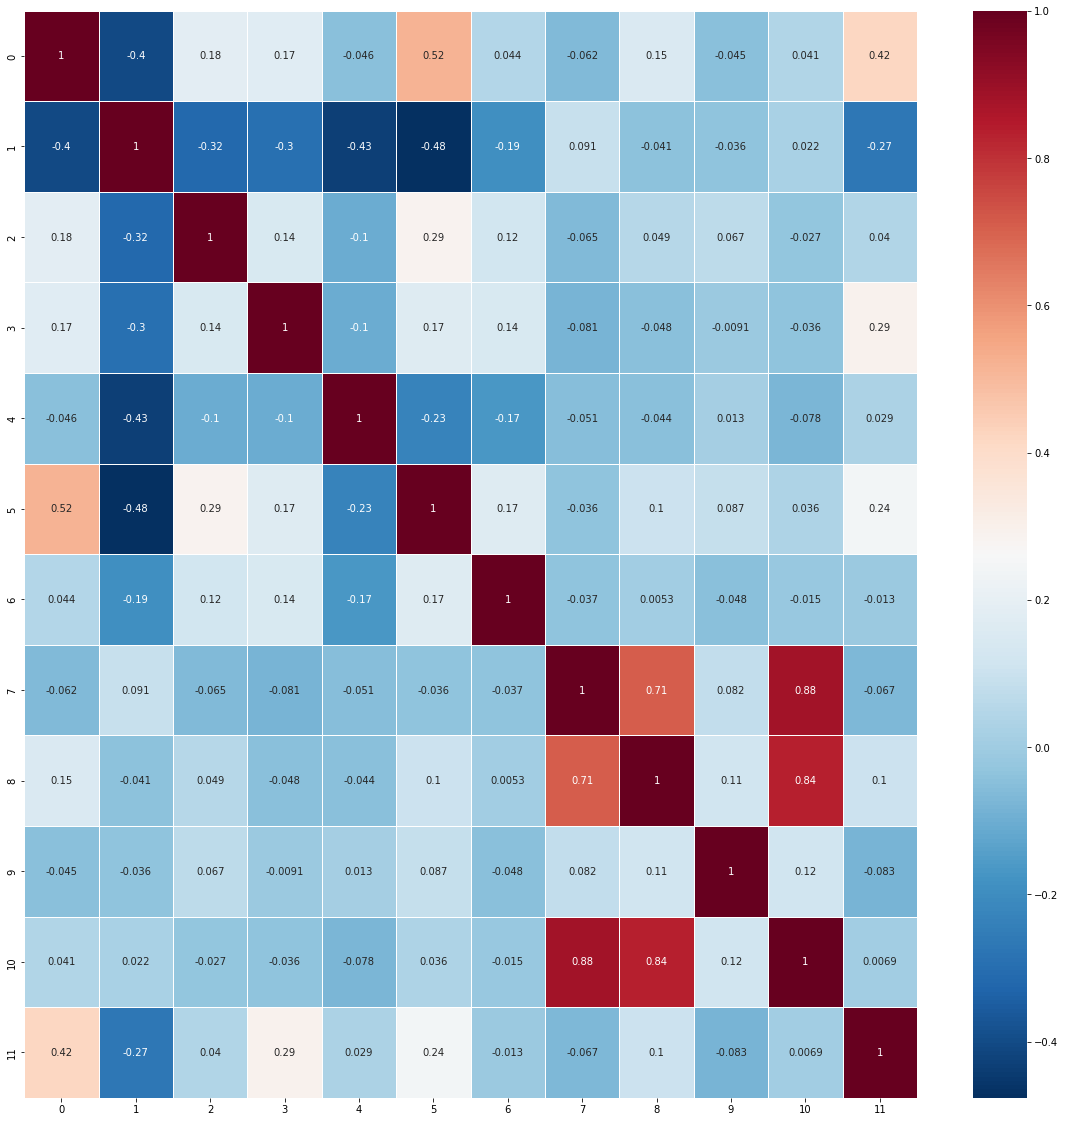

In [46]:
plt.figure(figsize=(20,20))
sns.heatmap(corrmatrix, annot=True, linewidths=0.7, cmap="RdBu_r",fmt='.2g')

On observe une forte corrélation avec la variable 7 avec les variable 8 et 10. 
La variable 7 correspond à la "population_population_number_of_people". 

In [47]:
#Vérification de la corrélation

import six

#population_population_number_of_people

for i in df3.columns:
    if not( isinstance(df3.select(i).take(1)[0][0], six.string_types)):
        print( "Correlation to population_population_number_of_people for ", i, df3.stat.corr('population_population_number_of_people',i))

Correlation to population_population_number_of_people for  gdp -0.06192635296862018
Correlation to population_population_number_of_people for  composition_food_organic_waste_percent 0.09057447010189341
Correlation to population_population_number_of_people for  composition_glass_percent -0.06513921837158097
Correlation to population_population_number_of_people for  composition_metal_percent -0.08113253419330961
Correlation to population_population_number_of_people for  composition_other_percent -0.05101209735205542
Correlation to population_population_number_of_people for  composition_paper_cardboard_percent -0.036281223951557154
Correlation to population_population_number_of_people for  composition_plastic_percent -0.03719186223017546
Correlation to population_population_number_of_people for  other_information_information_system_for_solid_waste_management -0.01977634178497943
Correlation to population_population_number_of_people for  other_information_national_agency_to_enforce_solid_w

## Modélisation Algorithmique

### Apprentissage supervisé

#### 1 - Arbre de décision

In [48]:
from pyspark.ml.feature import StringIndexer,VectorIndexer
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

In [49]:
X.printSchema()

root
 |-- region_id: string (nullable = true)
 |-- country_name: string (nullable = true)
 |-- gdp: double (nullable = true)
 |-- composition_food_organic_waste_percent: double (nullable = true)
 |-- composition_glass_percent: double (nullable = true)
 |-- composition_metal_percent: double (nullable = true)
 |-- composition_other_percent: double (nullable = true)
 |-- composition_paper_cardboard_percent: double (nullable = true)
 |-- composition_plastic_percent: double (nullable = true)
 |-- population_population_number_of_people: integer (nullable = true)
 |-- special_waste_e_waste_tons_year: double (nullable = true)
 |-- special_waste_hazardous_waste_tons_year: double (nullable = true)
 |-- total_msw_total_msw_generated_tons_year: double (nullable = true)
 |-- waste_treatment_recycling_percent: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- pcaFeatures: vector (nullable = true)



##### Utlisation du modèle

In [50]:
str_indx = StringIndexer(inputCol = "region_id", outputCol = "str_indx_label",stringOrderType="frequencyDesc").fit(X)

In [51]:
vec_indx = VectorIndexer(inputCol = "features", outputCol = "vec_indx_features", maxCategories = 4).fit(X)

In [52]:
tmp = ['gdp','composition_food_organic_waste_percent','composition_glass_percent','composition_metal_percent','composition_other_percent',
    'composition_paper_cardboard_percent','composition_plastic_percent','population_population_number_of_people','special_waste_e_waste_tons_year',
    'special_waste_hazardous_waste_tons_year','total_msw_total_msw_generated_tons_year','waste_treatment_recycling_percent','features']
(df_train, df_test) = X.randomSplit([0.70,0.30])

In [53]:
dt_class = DecisionTreeClassifier(labelCol = "str_indx_label", featuresCol = "features",maxDepth=5,impurity= "gini")

In [54]:
pipeline = Pipeline(stages=[str_indx, vec_indx, dt_class])

In [55]:
model_class = pipeline.fit(df_train)

In [56]:
df_pred = model_class.transform(df_test)

In [57]:
df_pred.toPandas()

,region_id,country_name,gdp,composition_food_organic_waste_percent,composition_glass_percent,composition_metal_percent,composition_other_percent,composition_paper_cardboard_percent,composition_plastic_percent,population_population_number_of_people,...,total_msw_total_msw_generated_tons_year,waste_treatment_recycling_percent,features,scaledFeatures,pcaFeatures,str_indx_label,vec_indx_features,rawPrediction,probability,prediction
0,EAS,American Samoa,11113.442380,19.70,3.40,7.90,25.60,26.40,12.80,55599,...,1.898949e+04,17.37,"[11113.44238, 19.7, 3.4, 7.9, 25.6, 26.4, 12.8...","[-0.5045347552179346, -1.373948962101728, -0.4...","[0.2880423986185639, 1.3440899899809187]",3.0,"[11113.44238, 19.7, 3.4, 7.9, 25.6, 26.4, 12.8...","[2.0, 3.0, 15.0, 3.0, 0.0, 0.0, 1.0]","[0.08333333333333333, 0.125, 0.625, 0.125, 0.0...",2.0
1,EAS,Australia,47784.179690,48.44,3.81,19.38,3.46,17.30,7.61,23789338,...,1.334500e+07,42.10,"[47784.17969, 48.44, 3.81, 19.38, 3.46, 17.3, ...","[1.1224537386248388, 0.4112943520422687, -0.31...","[-0.4310980317441848, 2.4551365388810233]",3.0,"[47784.17969, 48.44, 3.81, 19.38, 3.46, 17.3, ...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]",3.0
2,EAS,Japan,41309.957030,36.00,5.00,4.00,6.00,33.00,11.00,126529104,...,4.272000e+07,4.90,"[41309.95703, 36.0, 5.0, 4.0, 6.0, 33.0, 11.0,...","[0.8352087431029269, -0.36144144572917586, 0.0...","[-1.4054610649945078, 0.9853725984290848]",3.0,"[41309.95703, 36.0, 5.0, 4.0, 6.0, 33.0, 11.0,...","[2.0, 3.0, 15.0, 3.0, 0.0, 0.0, 1.0]","[0.08333333333333333, 0.125, 0.625, 0.125, 0.0...",2.0
3,EAS,Kiribati,2249.768555,43.60,5.50,10.00,9.30,10.90,16.50,114395,...,3.572383e+04,17.37,"[2249.768555, 43.6, 5.5, 10.0, 9.3, 10.9, 16.5...","[-0.8977936963878406, 0.11064794840771973, 0.2...","[0.6151662790153466, 0.14531028312372973]",3.0,"[2249.768555, 43.6, 5.5, 10.0, 9.3, 10.9, 16.5...","[0.0, 0.0, 0.0, 5.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]",3.0
4,EAS,Lao PDR,6543.666992,16.90,9.30,3.70,20.30,2.80,6.10,6663967,...,3.519000e+05,10.00,"[6543.666992, 16.9, 9.3, 3.7, 20.3, 2.8, 6.1, ...","[-0.7072842094454175, -1.5478766336258474, 1.5...","[0.6507107321999407, -0.2660208225998002]",3.0,"[6543.666992, 16.9, 9.3, 3.7, 20.3, 2.8, 6.1, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,SSF,Mozambique,1217.090210,60.00,4.76,4.28,15.00,25.00,11.69,27212382,...,2.500000e+06,1.00,"[1217.09021, 60.0, 4.76, 4.28, 15.0, 25.0, 11....","[-0.9436110403630168, 1.1293671673347045, 6.85...","[0.36075695988137074, -0.9179800886234277]",1.0,"[1217.09021, 60.0, 4.76, 4.28, 15.0, 25.0, 11....","[0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]",1.0
61,SSF,Nigeria,4690.379395,41.73,3.10,4.28,11.30,8.00,4.80,154402176,...,2.761483e+07,17.37,"[4690.379395, 41.73, 3.1, 4.28, 11.3, 8.0, 4.8...","[-0.7895099244783755, -0.005510889360174566, -...","[-0.7052954926630902, -1.2877897103666296]",1.0,"[4690.379395, 41.73, 3.1, 4.28, 11.3, 8.0, 4.8...","[1.0, 8.0, 1.0, 0.0, 1.0, 0.0, 0.0]","[0.09090909090909091, 0.7272727272727273, 0.09...",1.0
62,SSF,Seychelles,23302.953130,48.50,5.20,4.60,25.80,5.90,9.90,88303,...,4.800000e+04,17.37,"[23302.95313, 48.5, 5.2, 4.6, 25.8, 5.9, 9.9, ...","[0.036283215475406715, 0.4150213735749286, 0.1...","[0.6232792501681057, -0.6356001949347688]",1.0,"[23302.95313, 48.5, 5.2, 4.6, 25.8, 5.9, 9.9, ...","[1.0, 0.0, 1.0, 8.0, 0.0, 1.0, 0.0]","[0.09090909090909091, 0.0, 0.09090909090909091...",3.0
63,SSF,Tanzania,2128.553955,41.73,4.76,4.28,18.42,15.28,11.69,49082996,...,9.276995e+06,17.37,"[2128.553955, 41.73, 4.76, 4.28, 18.42, 15.28,...","[-0.9031716836865026, -0.005510889360174566, 6...","[0.18845927762369197, -0.4233382093806886]",1.0,"[2128.553955, 41.73, 4.76, 4.28, 18.42, 15.28,...","[0.0, 0.0, 0.0, 1.0, 0.0, 2.0, 0.0]","[0.0, 0.0, 0.0, 0.3333333333333333, 0.0, 0.666...",5.0


In [58]:
print(df_pred.printSchema())

root
 |-- region_id: string (nullable = true)
 |-- country_name: string (nullable = true)
 |-- gdp: double (nullable = true)
 |-- composition_food_organic_waste_percent: double (nullable = true)
 |-- composition_glass_percent: double (nullable = true)
 |-- composition_metal_percent: double (nullable = true)
 |-- composition_other_percent: double (nullable = true)
 |-- composition_paper_cardboard_percent: double (nullable = true)
 |-- composition_plastic_percent: double (nullable = true)
 |-- population_population_number_of_people: integer (nullable = true)
 |-- special_waste_e_waste_tons_year: double (nullable = true)
 |-- special_waste_hazardous_waste_tons_year: double (nullable = true)
 |-- total_msw_total_msw_generated_tons_year: double (nullable = true)
 |-- waste_treatment_recycling_percent: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- pcaFeatures: vector (nullable = true)
 |-- str_indx_label: double (nullable 

##### Evaluation

In [59]:
arb_acc = MulticlassClassificationEvaluator(labelCol="str_indx_label",predictionCol="prediction",metricName="accuracy")
arb_f1 = MulticlassClassificationEvaluator(labelCol="str_indx_label", predictionCol="prediction", metricName="f1")
arb_precision = MulticlassClassificationEvaluator(labelCol="str_indx_label", predictionCol="prediction", metricName="precisionByLabel")
arb_recall = MulticlassClassificationEvaluator(labelCol="str_indx_label", predictionCol="prediction", metricName="recallByLabel")
arb_auc = BinaryClassificationEvaluator(labelCol="str_indx_label", rawPredictionCol="prediction")

arb_acc_val = arb_acc.evaluate(df_pred)
arb_f1_val = arb_f1.evaluate(df_pred)
arb_precision_val = arb_precision.evaluate(df_pred)
arb_recall_val = arb_recall.evaluate(df_pred)

arb_auc_val = arb_auc.evaluate(df_pred)

print("Accuracy= %g " % arb_acc_val)
print("F1 = %g" % arb_f1_val)
print("Precision = %g" % arb_precision_val)
print("Recall = %g" % arb_recall_val)

print("AUC = %g" % arb_auc_val)

Accuracy= 0.523077 
F1 = 0.522026
Precision = 0.6
Recall = 0.545455
AUC = 0.671247


In [60]:
df_asm.select('region_id').groupBy('region_id').count().show()

+---------+-----+
|region_id|count|
+---------+-----+
|      ECS|   58|
|      SSF|   48|
|      LCN|   42|
|      MEA|   21|
|      EAS|   36|
|      SAS|    8|
|      NAC|    3|
+---------+-----+



In [61]:
df_pred.groupBy('population_population_number_of_people').count().show()

+--------------------------------------+-----+
|population_population_number_of_people|count|
+--------------------------------------+-----+
|                               1198575|    1|
|                              49082996|    1|
|                               5520314|    1|
|                              23789338|    1|
|                             103320224|    1|
|                              78736152|    1|
|                               5347896|    1|
|                                105481|    1|
|                               5521763|    1|
|                              16577147|    1|
|                                 55599|    1|
|                              14264756|    1|
|                                 13049|    1|
|                                612167|    1|
|                             154402176|    1|
|                             326687488|    1|
|                                 37783|    1|
|                                 54288|    1|
|            

In [62]:
df_pred.groupBy("region_id","str_indx_label", "prediction").count().show()

+---------+--------------+----------+-----+
|region_id|str_indx_label|prediction|count|
+---------+--------------+----------+-----+
|      ECS|           0.0|       2.0|    4|
|      SAS|           5.0|       1.0|    1|
|      SSF|           1.0|       2.0|    2|
|      LCN|           2.0|       0.0|    4|
|      SSF|           1.0|       5.0|    3|
|      NAC|           6.0|       0.0|    1|
|      EAS|           3.0|       2.0|    2|
|      LCN|           2.0|       1.0|    1|
|      ECS|           0.0|       1.0|    2|
|      EAS|           3.0|       3.0|    6|
|      LCN|           2.0|       2.0|    7|
|      EAS|           3.0|       5.0|    1|
|      SSF|           1.0|       3.0|    1|
|      EAS|           3.0|       0.0|    1|
|      MEA|           4.0|       3.0|    1|
|      ECS|           0.0|       3.0|    4|
|      SSF|           1.0|       1.0|    9|
|      ECS|           0.0|       0.0|   12|
|      LCN|           2.0|       3.0|    1|
|      MEA|           4.0|      

In [63]:
print(model_class.stages[2])

DecisionTreeClassificationModel: uid=DecisionTreeClassifier_7a42e67bc697, depth=5, numNodes=41, numClasses=7, numFeatures=12


##### Matrice de confusion

In [64]:
from sklearn.metrics import confusion_matrix

y_pred=df_pred.select("prediction").collect()
y_orig=df_pred.select("str_indx_label").collect()
cm = confusion_matrix(y_orig, y_pred)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[12  2  4  4  0  0  0]
 [ 0  9  2  1  0  3  0]
 [ 4  1  7  1  0  0  0]
 [ 1  0  2  6  0  1  0]
 [ 2  0  0  1  0  0  0]
 [ 0  1  0  0  0  0  0]
 [ 1  0  0  0  0  0  0]]


#### 2 - Forêt Aléatoire

In [65]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.feature import IndexToString

In [66]:
rf_waste = RandomForestClassifier(labelCol = "str_indx_label", featuresCol = "vec_indx_features",impurity= "gini",numTrees=3)	

##### Utilisation du modèle

In [67]:
# Convert indexed labels back to original labels.
labelConverter = IndexToString(inputCol="prediction", outputCol="predictedLabel",
                               labels=str_indx.labels)

# Chain indexers and forest in a Pipeline
rf_pipeline = Pipeline(stages=[str_indx, vec_indx, rf_waste, labelConverter])

# Train model.  This also runs the indexers.
rf_model = rf_pipeline.fit(df_train)

# Make predictions.
rf_pred = rf_model.transform(df_test)

rfModel = rf_model.stages[2]
print(rfModel)



RandomForestClassificationModel: uid=RandomForestClassifier_054a22e6be27, numTrees=3, numClasses=7, numFeatures=12


##### Evaluation

In [68]:
# Select (prediction, true label) and compute test error
rf_evaluator = MulticlassClassificationEvaluator(
    labelCol="str_indx_label", predictionCol="prediction", metricName="accuracy")
rf_accuracy = rf_evaluator.evaluate(rf_pred)
print("Accuracy = %g" % rf_accuracy)




rf_f1 = MulticlassClassificationEvaluator(labelCol="str_indx_label", predictionCol="prediction", metricName="f1")
rf_precision = MulticlassClassificationEvaluator(labelCol="str_indx_label", predictionCol="prediction", metricName="precisionByLabel")
rf_recall = MulticlassClassificationEvaluator(labelCol="str_indx_label", predictionCol="prediction", metricName="recallByLabel")
rf_auc = BinaryClassificationEvaluator(labelCol="str_indx_label", rawPredictionCol="prediction")

rf_f1_val = rf_f1.evaluate(rf_pred)
rf_precision_val = rf_precision.evaluate(rf_pred)
rf_recall_val = rf_recall.evaluate(rf_pred)

auc = rf_auc.evaluate(rf_pred)

print("F1 = %g" % rf_f1_val)
print("Precision = %g" % rf_precision_val)
print("Recall = %g" % rf_recall_val)

print("AUC = %g" % auc)

Accuracy = 0.569231
F1 = 0.583951
Precision = 0.8125
Recall = 0.590909
AUC = 0.704017


##### Matrice de confusion

In [69]:
y_rf_pred=rf_pred.select("prediction").collect()
y_rf_orig=rf_pred.select("str_indx_label").collect()
cm_rf = confusion_matrix(y_rf_orig, y_rf_pred)
print("Confusion Matrix:\n",cm_rf)

Confusion Matrix:
 [[13  1  4  2  1  1  0]
 [ 0 11  0  0  1  3  0]
 [ 1  3  7  1  1  0  0]
 [ 1  0  3  6  0  0  0]
 [ 0  1  2  0  0  0  0]
 [ 0  1  0  0  0  0  0]
 [ 1  0  0  0  0  0  0]]


In [70]:
rf_pred.toPandas()

,region_id,country_name,gdp,composition_food_organic_waste_percent,composition_glass_percent,composition_metal_percent,composition_other_percent,composition_paper_cardboard_percent,composition_plastic_percent,population_population_number_of_people,...,waste_treatment_recycling_percent,features,scaledFeatures,pcaFeatures,str_indx_label,vec_indx_features,rawPrediction,probability,prediction,predictedLabel
0,EAS,American Samoa,11113.442380,19.70,3.40,7.90,25.60,26.40,12.80,55599,...,17.37,"[11113.44238, 19.7, 3.4, 7.9, 25.6, 26.4, 12.8...","[-0.5045347552179346, -1.373948962101728, -0.4...","[0.2880423986185639, 1.3440899899809187]",3.0,"[11113.44238, 19.7, 3.4, 7.9, 25.6, 26.4, 12.8...","[0.07142857142857142, 0.2857142857142857, 0.14...","[0.02380952380952381, 0.09523809523809525, 0.0...",3.0,EAS
1,EAS,Australia,47784.179690,48.44,3.81,19.38,3.46,17.30,7.61,23789338,...,42.10,"[47784.17969, 48.44, 3.81, 19.38, 3.46, 17.3, ...","[1.1224537386248388, 0.4112943520422687, -0.31...","[-0.4310980317441848, 2.4551365388810233]",3.0,"[47784.17969, 48.44, 3.81, 19.38, 3.46, 17.3, ...","[1.1818181818181819, 0.0, 0.5454545454545454, ...","[0.393939393939394, 0.0, 0.1818181818181818, 0...",0.0,ECS
2,EAS,Japan,41309.957030,36.00,5.00,4.00,6.00,33.00,11.00,126529104,...,4.90,"[41309.95703, 36.0, 5.0, 4.0, 6.0, 33.0, 11.0,...","[0.8352087431029269, -0.36144144572917586, 0.0...","[-1.4054610649945078, 0.9853725984290848]",3.0,"[41309.95703, 36.0, 5.0, 4.0, 6.0, 33.0, 11.0,...","[0.6555023923444976, 0.0, 1.5612440191387558, ...","[0.2185007974481659, 0.0, 0.520414673046252, 0...",2.0,LCN
3,EAS,Kiribati,2249.768555,43.60,5.50,10.00,9.30,10.90,16.50,114395,...,17.37,"[2249.768555, 43.6, 5.5, 10.0, 9.3, 10.9, 16.5...","[-0.8977936963878406, 0.11064794840771973, 0.2...","[0.6151662790153466, 0.14531028312372973]",3.0,"[2249.768555, 43.6, 5.5, 10.0, 9.3, 10.9, 16.5...","[0.05555555555555555, 0.0, 0.0, 2.944444444444...","[0.018518518518518517, 0.0, 0.0, 0.98148148148...",3.0,EAS
4,EAS,Lao PDR,6543.666992,16.90,9.30,3.70,20.30,2.80,6.10,6663967,...,10.00,"[6543.666992, 16.9, 9.3, 3.7, 20.3, 2.8, 6.1, ...","[-0.7072842094454175, -1.5478766336258474, 1.5...","[0.6507107321999407, -0.2660208225998002]",3.0,"[6543.666992, 16.9, 9.3, 3.7, 20.3, 2.8, 6.1, ...","[0.625, 0.4, 1.725, 0.0, 0.0, 0.25, 0.0]","[0.20833333333333334, 0.13333333333333333, 0.5...",2.0,LCN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,SSF,Mozambique,1217.090210,60.00,4.76,4.28,15.00,25.00,11.69,27212382,...,1.00,"[1217.09021, 60.0, 4.76, 4.28, 15.0, 25.0, 11....","[-0.9436110403630168, 1.1293671673347045, 6.85...","[0.36075695988137074, -0.9179800886234277]",1.0,"[1217.09021, 60.0, 4.76, 4.28, 15.0, 25.0, 11....","[0.18181818181818182, 1.9090909090909092, 0.54...","[0.060606060606060615, 0.6363636363636365, 0.1...",1.0,SSF
61,SSF,Nigeria,4690.379395,41.73,3.10,4.28,11.30,8.00,4.80,154402176,...,17.37,"[4690.379395, 41.73, 3.1, 4.28, 11.3, 8.0, 4.8...","[-0.7895099244783755, -0.005510889360174566, -...","[-0.7052954926630902, -1.2877897103666296]",1.0,"[4690.379395, 41.73, 3.1, 4.28, 11.3, 8.0, 4.8...","[0.8508403361344538, 0.8781512605042017, 0.235...","[0.28361344537815125, 0.2927170868347339, 0.07...",1.0,SSF
62,SSF,Seychelles,23302.953130,48.50,5.20,4.60,25.80,5.90,9.90,88303,...,17.37,"[23302.95313, 48.5, 5.2, 4.6, 25.8, 5.9, 9.9, ...","[0.036283215475406715, 0.4150213735749286, 0.1...","[0.6232792501681057, -0.6356001949347688]",1.0,"[23302.95313, 48.5, 5.2, 4.6, 25.8, 5.9, 9.9, ...","[0.08163265306122448, 0.061224489795918366, 0....","[0.027210884353741496, 0.02040816326530612, 0....",4.0,MEA
63,SSF,Tanzania,2128.553955,41.73,4.76,4.28,18.42,15.28,11.69,49082996,...,17.37,"[2128.553955, 41.73, 4.76, 4.28, 18.42, 15.28,...","[-0.9031716836865026, -0.005510889360174566, 6...","[0.18845927762369197, -0.4233382093806886]",1.0,"[2128.553955, 41.73, 4.76, 4.28, 18.42, 15.28,...","[0.1357142857142857, 2.294805194805195, 0.0285...","[0.0452380

#### 3 - Régression linéaire

In [71]:
from pyspark.ml.regression import LinearRegression

##### Utilisation du modèle

In [72]:
lr = LinearRegression(labelCol="label",featuresCol='pcaFeatures', maxIter=40, regParam=0.3, elasticNetParam=0.8)

df_tmp_train = df_train
df_tmp_test = df_test
str_indx = StringIndexer(inputCol = "region_id", outputCol = "label",stringOrderType="frequencyDesc").fit(df_tmp_train)
df_tmp_train = str_indx.transform(df_tmp_train)

str_indx2 = StringIndexer(inputCol = "region_id", outputCol = "label",stringOrderType="frequencyDesc").fit(df_tmp_test)
df_tmp_test = str_indx2.transform(df_tmp_test)
# Fit the model

lr_pipeline = Pipeline(stages=[vec_indx,lr])
lrModel = lr_pipeline.fit(df_tmp_train)

lr_model= lrModel.stages[1]



##### Evaluation

In [73]:
# Print the coefficients and intercept for linear regression
print("Coefficients: %s" % str(lr_model.coefficients))
print("Intercept: %s" % str(lr_model.intercept))

# Summarize the model over the training set and print out some metrics
trainingSummary = lr_model.summary
print("nombre Iterations: %d" % trainingSummary.totalIterations)
print("objectiveHistory: %s" % str(trainingSummary.objectiveHistory))
trainingSummary.residuals.show()


Coefficients: [0.0,0.0]
Intercept: 1.9072847682119205
nombre Iterations: 0
objectiveHistory: [0.5]
+------------------+
|         residuals|
+------------------+
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
|1.0927152317880795|
+------------------+
only showing top 20 rows



In [74]:
print("MSE: %f" % trainingSummary.meanSquaredError)
print("RMSE: %f" % trainingSummary.rootMeanSquaredError)
print("r2: %f" % trainingSummary.r2)
# Mean absolute error
print("MAE = %f" % trainingSummary.meanAbsoluteError)
# Explained variance
print("Explained variance = %f" % trainingSummary.explainedVariance)

MSE: 2.441735
RMSE: 1.562605
r2: 0.000000
MAE = 1.305995
Explained variance = -0.000000


In [75]:
lr_predictions = lr_model.transform(df_tmp_test)

In [76]:
lr_predictions.printSchema()

root
 |-- region_id: string (nullable = true)
 |-- country_name: string (nullable = true)
 |-- gdp: double (nullable = true)
 |-- composition_food_organic_waste_percent: double (nullable = true)
 |-- composition_glass_percent: double (nullable = true)
 |-- composition_metal_percent: double (nullable = true)
 |-- composition_other_percent: double (nullable = true)
 |-- composition_paper_cardboard_percent: double (nullable = true)
 |-- composition_plastic_percent: double (nullable = true)
 |-- population_population_number_of_people: integer (nullable = true)
 |-- special_waste_e_waste_tons_year: double (nullable = true)
 |-- special_waste_hazardous_waste_tons_year: double (nullable = true)
 |-- total_msw_total_msw_generated_tons_year: double (nullable = true)
 |-- waste_treatment_recycling_percent: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- pcaFeatures: vector (nullable = true)
 |-- label: double (nullable = false)


In [77]:
lr_predictions.select("prediction", "label", "pcaFeatures").show(5)

+------------------+-----+--------------------+
|        prediction|label|         pcaFeatures|
+------------------+-----+--------------------+
|1.9072847682119205|  3.0|[0.28804239861856...|
|1.9072847682119205|  3.0|[-0.4310980317441...|
|1.9072847682119205|  3.0|[-1.4054610649945...|
|1.9072847682119205|  3.0|[0.61516627901534...|
|1.9072847682119205|  3.0|[0.65071073219994...|
+------------------+-----+--------------------+
only showing top 5 rows



In [78]:
from pyspark.ml.evaluation import RegressionEvaluator
lr_evaluator = RegressionEvaluator(predictionCol="prediction", \
                 labelCol="label",metricName="rmse")
print("Root Mean Squared Error (RMSE) on test data = %g" % lr_evaluator.evaluate(lr_predictions))

Root Mean Squared Error (RMSE) on test data = 1.48781


In [79]:
df_tmp_train.describe().toPandas()

,summary,region_id,country_name,gdp,composition_food_organic_waste_percent,composition_glass_percent,composition_metal_percent,composition_other_percent,composition_paper_cardboard_percent,composition_plastic_percent,population_population_number_of_people,special_waste_e_waste_tons_year,special_waste_hazardous_waste_tons_year,total_msw_total_msw_generated_tons_year,waste_treatment_recycling_percent,label
0,count,151,151,151,151,151,151,151,151,151,151,151,151,151,151,151
1,mean,None,None,21578.246092364232,42.56558315900659,4.800897528827813,4.1737906715364215,18.43650213185431,14.924407621788088,11.866913663854318,2.7802380139072847E7,228893.46880794692,7326128.786966883,8146599.71426523,17.555193194105925,1.9072847682119205
2,stddev,None,None,20759.346859257595,16.35630786369406,3.2255937511729154,3.061031013723745,14.965058612247711,7.9905526927996275,5.062777625445676,1.1846170320871654E8,693103.046570187,3.6395605019007586E7,3.359021659364741E7,10.867098721335704,1.567805231855383
3,min,EAS,Afghanistan,822.6104736,4.8,0.0,0.1,0.8,2.0,1.61,11097,10.0,4.92,3989.4865,9.7E-4,0.0
4,max,SSF,Zimbabwe,97341.46875,87.6,21.4,19.12,92.7,47.0,32.0,1400050048,7211000.0,4.48E8,3.95081376E8,67.0,6.0


### Apprentissage Non Supervisé

#### K-means

##### Version 1

In [80]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# Trains a k-means model.
kmeans = KMeans().setK(5).setSeed(1)
k_model = kmeans.fit(df_asm.select("region_id","features"))

# Make predictions
k_pred = k_model.transform(df_asm)

# Evaluate clustering by computing Silhouette score
evaluator = ClusteringEvaluator()

silhouette = evaluator.evaluate(k_pred)
print("Silhouette with squared euclidean distance = " + str(silhouette))



# Shows the result.
centers = k_model.clusterCenters()
print("Cluster Centers: ")
for center in centers:
    print(center)

Silhouette with squared euclidean distance = 0.9010827675575445
Cluster Centers: 
[2.28274188e+04 4.10519848e+01 4.80059858e+00 4.44939063e+00
 1.88558644e+01 1.53548474e+01 1.17699169e+01 9.73405660e+06
 1.21952276e+05 3.89632900e+06 3.01245265e+06 1.76260320e+01]
[1.12945542e+04 5.14650000e+01 3.43000000e+00 2.69000000e+00
 1.57600000e+01 1.24400000e+01 1.07450000e+01 1.37633370e+09
 4.45550000e+06 2.10597000e+07 2.92415688e+08 1.11850000e+01]
[1.15346377e+04 3.70000000e+01 5.00000000e+00 4.00000000e+00
 2.20000000e+01 2.50000000e+01 7.00000000e+00 4.50046440e+07
 2.77000000e+05 4.48000000e+08 1.52420250e+07 3.20000000e+00]
[1.87095606e+04 5.02621053e+01 4.49368421e+00 2.52842105e+00
 1.50936842e+01 1.29115789e+01 1.06873684e+01 1.19697770e+08
 9.15747318e+05 1.19444591e+07 3.35591319e+07 1.52694737e+01]
[6.14983711e+04 1.49000000e+01 4.40000000e+00 9.00000000e+00
 3.20000000e+00 2.66000000e+01 1.29000000e+01 3.26687488e+08
 2.44000000e+06 2.88000000e+07 2.65224528e+08 3.46000000e+01

In [81]:
sum = k_model.summary

In [82]:
print("Within Set Sum of Squared Errors = %g" % sum.trainingCost)

Within Set Sum of Squared Errors = 1.33026e+17


In [83]:
k_model.getMaxIter()

20

In [84]:
kmeans_path = "../data/kmeans"
kmeans.save(kmeans_path)

Py4JJavaError: An error occurred while calling o2203.save.
: java.io.IOException: Path ../data/kmeans already exists. To overwrite it, please use write.overwrite().save(path) for Scala and use write().overwrite().save(path) for Java and Python.
	at org.apache.spark.ml.util.FileSystemOverwrite.handleOverwrite(ReadWrite.scala:683)
	at org.apache.spark.ml.util.MLWriter.save(ReadWrite.scala:167)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke(NativeMethodAccessorImpl.java:62)
	at java.base/jdk.internal.reflect.DelegatingMethodAccessorImpl.invoke(DelegatingMethodAccessorImpl.java:43)
	at java.base/java.lang.reflect.Method.invoke(Method.java:566)
	at py4j.reflection.MethodInvoker.invoke(MethodInvoker.java:244)
	at py4j.reflection.ReflectionEngine.invoke(ReflectionEngine.java:357)
	at py4j.Gateway.invoke(Gateway.java:282)
	at py4j.commands.AbstractCommand.invokeMethod(AbstractCommand.java:132

23/01/30 16:12:49 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 2567983 ms exceeds timeout 120000 ms
23/01/30 16:12:49 WARN SparkContext: Killing executors is not supported by current scheduler.


###### Affichage des clusters

In [ ]:
import numpy as np
x_pca = np.array(df_pca.rdd.map(lambda row: row.pcaFeatures).collect())

In [ ]:
cluster_kmeans = np.array(k_pred.rdd.map(lambda row: row.prediction).collect()).reshape(-1,1)

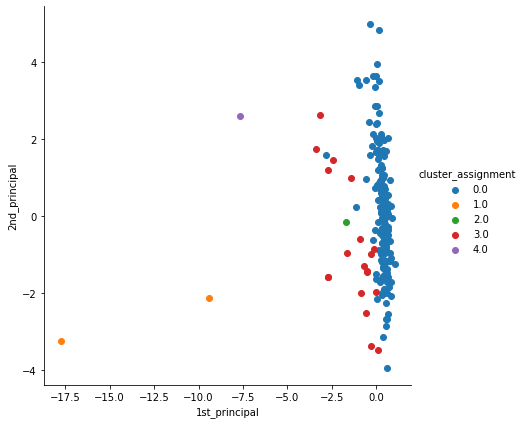

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pca_d = np.hstack((x_pca,cluster_kmeans))

pca_dataframe = pd.DataFrame(data=pca_d, columns=("1st_principal", "2nd_principal","cluster_assignment"))
sns.FacetGrid(pca_dataframe,hue="cluster_assignment", height=6).map(plt.scatter, '1st_principal', '2nd_principal' ).add_legend()

plt.show()

##### Version 2

In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
silhouette_score=[]
evaluator_v2 = ClusteringEvaluator(predictionCol='prediction', featuresCol='scaledFeatures', \
                                metricName='silhouette', distanceMeasure='squaredEuclidean')
for i in range(2,10):
    
    KMeans_algo=KMeans(featuresCol='scaledFeatures', k=i)
    
    KMeans_fit=KMeans_algo.fit(df_scaled)
    
    output=KMeans_fit.transform(df_scaled)
    
    
    
    score=evaluator_v2.evaluate(output)
    
    silhouette_score.append(score)
    
    print("Silhouette Score:",score)

Silhouette Score: 0.33894183576926223
Silhouette Score: 0.38422570009319196
Silhouette Score: 0.376726637171798
Silhouette Score: 0.17742133800847995
Silhouette Score: 0.23232699237458157
Silhouette Score: 0.22018805620803691
Silhouette Score: 0.2815481289475318
Silhouette Score: 0.21770225741583235


Text(0, 0.5, 'cost')

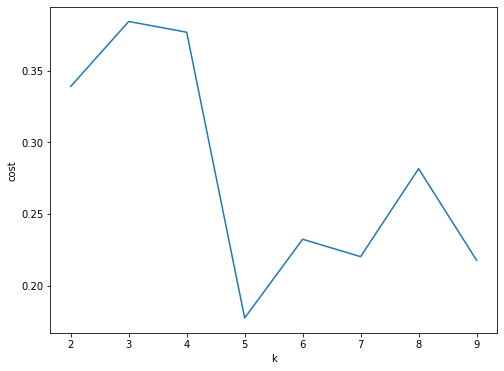

In [ ]:
fig, ax = plt.subplots(1,1, figsize =(8,6))
ax.plot(range(2,10),silhouette_score)
ax.set_xlabel('k')
ax.set_ylabel('cost')

In [ ]:
from pyspark.mllib.linalg import Vectors
def transData(data):
    return data.rdd.map(lambda r: [Vectors.dense(r[:-1])]).toDF(['features'])

#### Gaussian Mixture Model (GMM)

In [ ]:
from pyspark.ml.clustering import GaussianMixture

gmm = GaussianMixture().setK(2).setSeed(538009335)
gmm_model = gmm.fit(df_asm)

print("Gaussians shown as a DataFrame: ")
gmm_model.gaussiansDF.toPandas().transpose()

23/01/30 13:56:15 WARN BLAS: Failed to load implementation from: com.github.fommil.netlib.NativeSystemBLAS
23/01/30 13:56:15 WARN BLAS: Failed to load implementation from: com.github.fommil.netlib.NativeRefBLAS
Gaussians shown as a DataFrame: 


,0,1
mean,"[22485.164763028686, 41.818717856527755, 4.759...","[22485.164763028686, 41.818717856527755, 4.759..."
cov,"DenseMatrix([[ 5.05655843e+08, -1.45180596e+05...","DenseMatrix([[ 5.05655843e+08, -1.45180596e+05..."
